In [25]:
import pandas as pd


df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')


df["Profit_Margin"] = df["Profit"] / df["Sales"]


df["Is_Loss"] = df["Profit"] < 0


category_summary = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Profit_Margin=("Profit_Margin", "mean"),
    Total_Orders=("Order ID", "count"),
    Loss_Orders=("Is_Loss", "sum")
).reset_index()


category_summary["Loss_Rate"] = category_summary["Loss_Orders"] / category_summary["Total_Orders"]


category_summary = category_summary.sort_values(by="Total_Profit")

category_summary

,Category,Total_Sales,Total_Profit,Avg_Profit_Margin,Total_Orders,Loss_Orders,Loss_Rate
0,Furniture,741999.7953,18451.2728,0.038784,2121,714,0.336634
1,Office Supplies,719047.0320,122490.8008,0.138030,6026,886,0.147030
2,Technology,836154.0330,145454.9481,0.156138,1847,271,0.146724


Furniture is not loss-making overall, but it has a significantly higher loss rate and much lower profitability compared to other categories.

Although Furniture generates comparable sales to other categories, it contributes disproportionately low profit and exhibits a significantly higher loss rate. This suggests inefficiencies in pricing or discount strategies within this category.

Furniture is a high-revenue but low-efficiency category, with the highest loss rate (33.6%) and significantly lower profit compared to other categories.

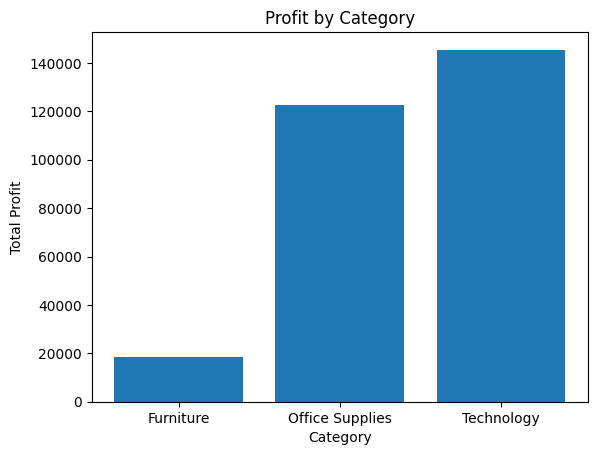

In [26]:
import matplotlib.pyplot as plt

plt.bar(category_summary["Category"], category_summary["Total_Profit"])
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

Technology is the most profitable category, while Furniture generates high revenue but significantly lower profitability. This indicates a potential pricing or discounting issue within the Furniture category.

In [27]:
category_summary["Profit_Margin_%"] = category_summary["Total_Profit"] / category_summary["Total_Sales"]

In [28]:


subcat_summary = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Orders=("Order ID", "count"),
    Loss_Orders=("Is_Loss", "sum")
).reset_index()

# profit margin
subcat_summary["Profit_Margin"] = subcat_summary["Total_Profit"] / subcat_summary["Total_Sales"]

# loss rate
subcat_summary["Loss_Rate"] = subcat_summary["Loss_Orders"] / subcat_summary["Total_Orders"]

# sort
subcat_summary = subcat_summary.sort_values(by="Total_Profit")

subcat_summary

,Sub-Category,Total_Sales,Total_Profit,Total_Orders,Loss_Orders,Profit_Margin,Loss_Rate
16,Tables,206965.5320,-17725.4811,319,203,-0.085645,0.636364
4,Bookcases,114879.9963,-3472.5560,228,109,-0.030228,0.478070
15,Supplies,46673.5380,-1189.0995,190,33,-0.025477,0.173684
8,Fasteners,3024.2800,949.5182,217,12,0.313965,0.055300
11,Machines,189238.6310,3384.7569,115,44,0.017886,0.382609
10,Labels,12486.3120,5546.2540,364,0,0.444187,0.000000
2,Art,27118.7920,6527.7870,796,0,0.240711,0.000000
7,Envelopes,16476.4020,6964.1767,254,0,0.422676,0.000000
9,Furnishings,91705.1640,13059.1436,957,167,0.142404,0.174504
1,Appliances,107532.1610,18138.0054,466,67,0.168675,0.143777


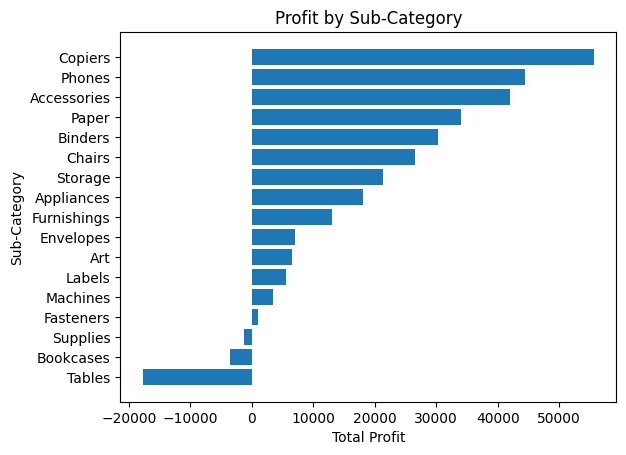

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(subcat_summary["Sub-Category"], subcat_summary["Total_Profit"])
plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()

The analysis reveals that the Tables sub-category is the primary driver of losses, despite contributing significantly to overall sales. This suggests structural issues such as aggressive discounting or poor pricing strategy.

In [30]:
worst_5 = subcat_summary.head(5)
best_5 = subcat_summary.tail(5)

worst_5, best_5

(   Sub-Category  Total_Sales  Total_Profit  Total_Orders  Loss_Orders  \
 16       Tables  206965.5320   -17725.4811           319          203   
 4     Bookcases  114879.9963    -3472.5560           228          109   
 15     Supplies   46673.5380    -1189.0995           190           33   
 8     Fasteners    3024.2800      949.5182           217           12   
 11     Machines  189238.6310     3384.7569           115           44   
 
     Profit_Margin  Loss_Rate  
 16      -0.085645   0.636364  
 4       -0.030228   0.478070  
 15      -0.025477   0.173684  
 8        0.313965   0.055300  
 11       0.017886   0.382609  ,
    Sub-Category  Total_Sales  Total_Profit  Total_Orders  Loss_Orders  \
 3       Binders   203412.733    30221.7633          1523          613   
 12        Paper    78479.206    34053.5693          1370            0   
 0   Accessories   167380.318    41936.6357           775           91   
 13       Phones   330007.054    44515.7306           889        

Top 5 loss-driving sub-categories vs top 5 profit-driving sub-categories

In [31]:
subcat_summary["Profit_per_Order"] = subcat_summary["Total_Profit"] / subcat_summary["Total_Orders"]

In [32]:
# region + category pivot (profit)

heatmap_data = df.pivot_table(
    values="Profit",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

heatmap_data

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3046.1658,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496


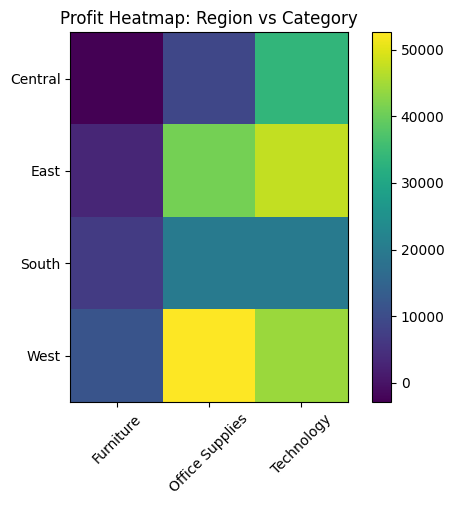

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(heatmap_data)

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.title("Profit Heatmap: Region vs Category")
plt.colorbar()

plt.show()

The heatmap analysis shows that losses are not uniformly distributed. The Furniture category performs particularly poorly in the West region, indicating region-specific pricing or discounting issues.

In [34]:
sales_heatmap = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

sales_heatmap

Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


Some regions generate strong sales but fail to convert them into profit, suggesting inefficiencies in discounting or cost structures.

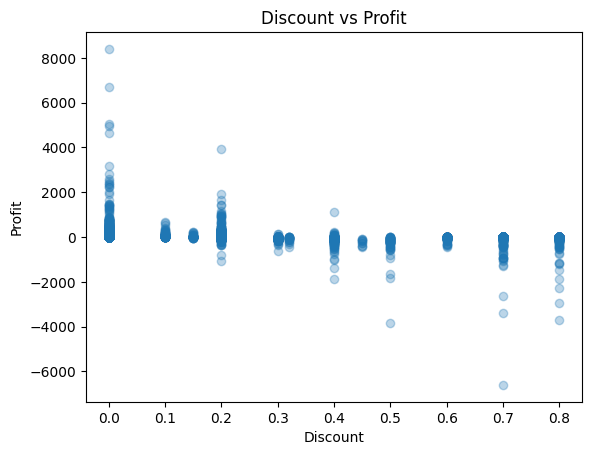

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [36]:
# discount bucket
df["Discount_Bucket"] = pd.cut(
    df["Discount"],
    bins=[0, 0.1, 0.2, 0.3, 0.5, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-50%", "50%+"]
)

bucket_summary = df.groupby("Discount_Bucket").agg(
    Avg_Profit=("Profit", "mean"),
    Total_Orders=("Order ID", "count")
).reset_index()

bucket_summary

/tmp/ipykernel_4106/4038475081.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = df.groupby("Discount_Bucket").agg(


,Discount_Bucket,Avg_Profit,Total_Orders
0,0-10%,96.055074,94
1,10-20%,24.738824,3709
2,20-30%,-45.679636,227
3,30-50%,-156.282991,310
4,50%+,-89.438144,856


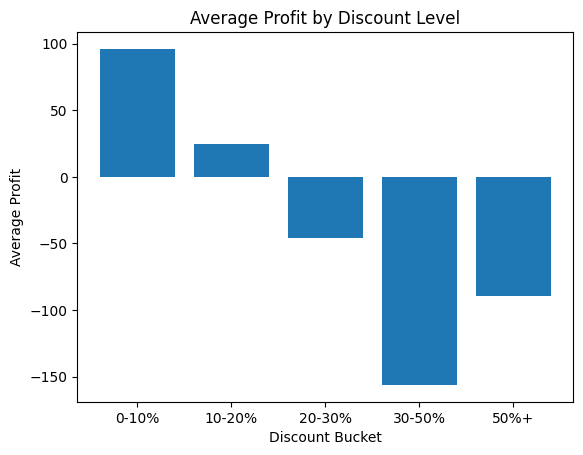

In [37]:
plt.figure()
plt.bar(bucket_summary["Discount_Bucket"], bucket_summary["Avg_Profit"])

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Profit")

plt.show()

The analysis shows a strong negative relationship between discount levels and profitability. Orders with discounts above 20% are significantly more likely to result in financial loss.

In [38]:
loss_by_discount = df.groupby("Discount_Bucket")["Is_Loss"].mean().reset_index()
loss_by_discount.rename(columns={"Is_Loss": "Loss_Rate"}, inplace=True)

loss_by_discount

/tmp/ipykernel_4106/1562773029.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_by_discount = df.groupby("Discount_Bucket")["Is_Loss"].mean().reset_index()


,Discount_Bucket,Loss_Rate
0,0-10%,0.042553
1,10-20%,0.139930
2,20-30%,0.916300
3,30-50%,0.916129
4,50%+,1.000000


As discount increases, not only does profit decrease, but the probability of loss-making orders increases significantly.

In [39]:
numeric_df = df[["Sales", "Profit", "Discount", "Quantity"]]

In [40]:
corr_matrix = numeric_df.corr()
corr_matrix

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


While correlation analysis shows a moderate negative relationship between discount and profit, deeper analysis reveals a strong nonlinear effect, particularly beyond the 20% discount threshold.

The primary driver of losses is excessive discounting, particularly within the Tables sub-category, where high discount levels push a majority of orders into negative profitability.

🔹 Recommendations
Implement a discount cap (max 20%) for loss-prone sub-categories such as Tables
Introduce margin-based discount controls to prevent negative-profit orders
Re-evaluate pricing strategy for Furniture products
Focus growth on high-margin sub-categories like Copiers and Phones

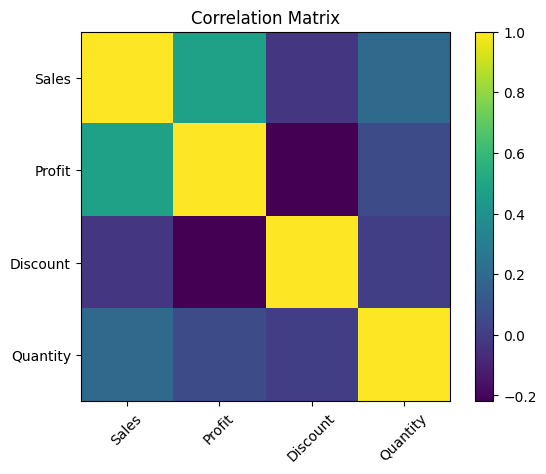

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr_matrix)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.colorbar()

plt.show()

Discount shows a strong negative correlation with profit, confirming that aggressive discounting is a key driver of financial losses. Sales and quantity, on the other hand, show weaker relationships with profitability.

In [42]:
# target variable
df["Is_Loss"] = (df["Profit"] < 0).astype(int)

In [43]:
features = ["Discount", "Sales", "Quantity"]
X = df[features]
y = df["Is_Loss"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1632    4]
 [ 111  252]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1636
           1       0.98      0.69      0.81       363

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.89      1999
weighted avg       0.95      0.94      0.94      1999



In [48]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Discount,16.204585
1,Sales,0.000204
2,Quantity,-0.065878


The classification model confirms that discount is the strongest predictor of loss-making orders. As discount levels increase, the likelihood of an order being unprofitable rises significantly.A simple predictive model can help identify high-risk orders before they are finalized, enabling better discount control and pricing decisions.

Analyzed retail sales data to identify key drivers of unprofitable orders, built an Excel dashboard and validated findings using Python, and developed a classification model to predict loss-making transactions.

🔹 Recommendations
Implement a strict discount cap at 20% for high-risk sub-categories
Introduce a predictive alert system to flag potential loss-making orders.
Reassess pricing strategy for Furniture products, especially Tables
Prioritize sales growth in high-margin categories such as Technology